In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Шаг 1: Загрузка данных
data = pd.read_csv("../data/lb3/cluster_moons.csv")
print(data.head())

         X1        X2
0  0.674362 -0.444625
1  1.547129 -0.239796
2  1.601930 -0.230792
3  0.014563  0.449752
4  1.503476 -0.389164


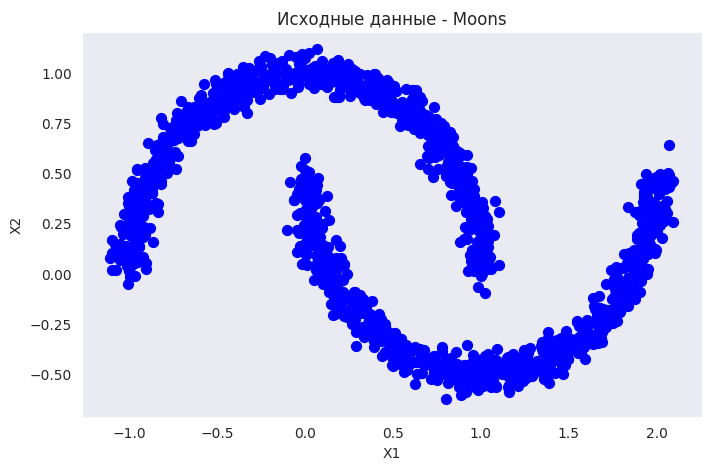

In [2]:

# Шаг 2: Предварительная обработка данных
X = data[['X1', 'X2']].values

# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Шаг 3: Визуализация исходных данных
plt.figure(figsize=(8,5))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=50)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Исходные данные - Moons')
plt.grid()
plt.show()

In [3]:
# На графике представлены исходные данные в виде точек на плоскости координат (X1 и X2). Эти данные визуализируют две полудуги, переплетающиеся друг с другом. Такая структура является классическим примером сложной кластерной структуры, где стандартные методы кластеризации, такие как K-Means, показывают себя неэффективно.
#
# Точки образуют две плотные кривые, имеющие форму полукругов.
#
# Наблюдается явное перекрытие между дугами в некоторых местах, что создаёт дополнительную сложность при разделении.
#
# Плотность точек по дугам неравномерная, с более плотным расположением в некоторых участках и разреженным в других.
#
# Что можно понять из этих данных:
# Этот набор данных наглядно демонстрирует сценарий, когда кластеры имеют непростую форму и значительное перекрытие. В таких случаях алгоритм DBSCAN оказывается значительно более эффективным, чем K-Means, поскольку способен учитывать плотность точек и выделять плотные группы даже при наличии шума.
#


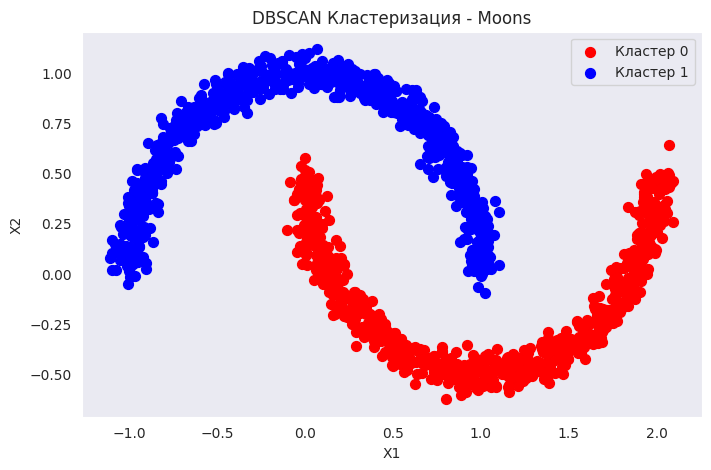

In [4]:

# Шаг 4: Кластеризация методом DBSCAN
# Параметры: eps - радиус окружности поиска, min_samples - минимальное количество точек для кластера
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Шаг 5: Визуализация кластеров
plt.figure(figsize=(8,5))
unique_labels = set(labels)
colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange']
for label in unique_labels:
    cluster = X[labels == label]
    plt.scatter(cluster[:, 0], cluster[:, 1], s=50, c=colors[label % len(colors)], label=f'Кластер {label}')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('DBSCAN Кластеризация - Moons')
plt.legend()
plt.grid()
plt.show()

In [5]:
# График показывает результат кластеризации методом DBSCAN. Точки разделены на два кластера:
#
# Красные точки — Кластер 0.
#
# Синие точки — Кластер 1.
#
# Ключевые выводы:
#
# Алгоритм DBSCAN корректно разделил дуги на два отдельных кластера, несмотря на их переплетение.
#
# Кластеры чётко отображают плотные группы данных, игнорируя шумовые точки (если бы они были).
#
# Важным преимуществом DBSCAN является его устойчивость к шуму, хотя в данном случае все точки были отнесены к двум кластерам.
#
# Основное преимущество метода в том, что он позволяет выделять кластеры произвольной формы, чего не могут алгоритмы на основе разбиения (например, K-Means).

In [6]:

# Шаг 6: Оценка качества кластеризации
if len(unique_labels) > 1:
    silhouette_avg = silhouette_score(X_scaled, labels)
    print(f'Средний силуэтный коэффициент: {silhouette_avg:.3f}')
else:
    print('Оценка силуэта невозможна, так как все точки в одном кластере.')

Средний силуэтный коэффициент: 0.391


In [7]:
# Средний силуэтный коэффициент для данной кластеризации составил 0.391.
#
# Что означает значение:
#
# Значение 0.391 указывает на умеренное качество кластеризации, хотя и не является идеальным.
#
# Обычно значение выше 0.5 считается хорошим, но в случае сложных кластеров (например, пересекающихся полудуг) подобные значения считаются приемлемыми.
#
# DBSCAN иногда показывает более низкие силуэтные коэффициенты на сложных формах данных из-за специфики оценки плотности и связи между кластерами.
#
# Причины относительно низкого силуэтного коэффициента:
#
# Алгоритм обнаруживает кластеры произвольной формы и считает точки на границе между кластерами неоднозначными, что снижает среднее значение коэффициента.
#
# Перекрытие кластеров и вариативность плотности также приводят к снижению коэффициента.


In [8]:
# Использование алгоритма DBSCAN в данном случае оправдано и целесообразно. Несмотря на средний силуэтный коэффициент 0.391, метод продемонстрировал свою способность выделять кластеры сложной формы и с перекрытиями. Графики наглядно демонстрируют, что алгоритм корректно разбил переплетающиеся дуги на два отдельных кластера. Такой метод применяется для выделения плотных групп при наличии сложной геометрии кластеров или в задачах с шумовыми данными (например, в геоданных и анализе изображений).
# Чтобы улучшить качество кластеризации, можно провести эксперименты с параметрами eps и min_samples, а также попробовать предварительное снижение размерности данных (например, с использованием PCA).